In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [10]:
#Leemos el dataframe limpio y listo para el analisis predictivo

df = pd.read_csv('/content/csv_limpio_para_ml.csv')
df.head()

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly
0,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6
1,0.0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9
2,1.0,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9
3,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0
4,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9


# **Encoding**

In [12]:
# 1. Identificar las columnas que son de texto (categóricas)
# Excluimos 'Churn' porque ya la convertimos a numérica (0 y 1)
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()
print(f"Transformando estas columnas: {columnas_categoricas}")

# 2. Aplicar One-Hot Encoding
# drop_first=True ayuda a evitar la redundancia (trampa de la variable ficticia)
df_final_ml = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# 3. Verificar el resultado
print(f"\nNueva forma del dataset: {df_final_ml.shape}")
print("Primeras 5 filas con datos numéricos:")
df_final_ml.head()

Transformando estas columnas: ['customer_gender', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod']

Nueva forma del dataset: (7267, 30)
Primeras 5 filas con datos numéricos:


,Churn,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_No phone service,phone_MultipleLines_Yes,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0.0,0,9,65.6,False,True,True,True,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0.0,0,9,59.9,True,False,False,True,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1.0,0,4,73.9,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1.0,1,13,98.0,True,True,False,True,False,False,...,False,True,False,True,False,False,True,False,True,False
4,1.0,1,3,83.9,False,True,False,True,False,False,...,False,True,False,False,False,False,True,False,False,True


# **Verificación de la Proporción de Cancelación (Churn)**

--- Análisis de Clases ---
Clientes que se QUEDAN (0): 5174 (73.46%)
Clientes que se VAN (1): 1869 (26.54%)


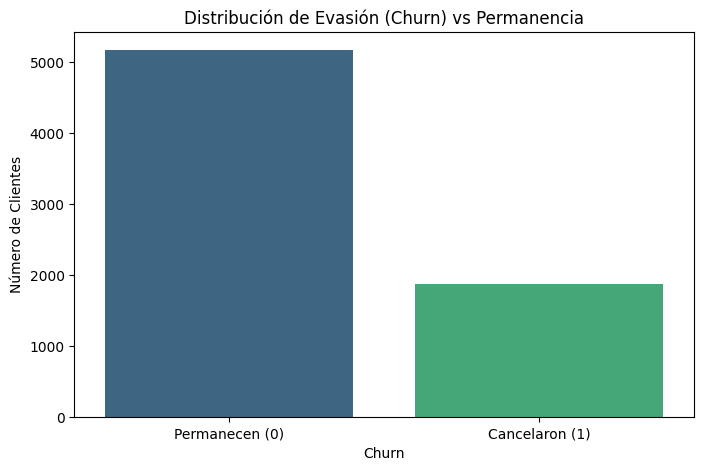

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Contar los valores de la columna 'Churn'
conteos = df_final_ml['Churn'].value_counts()
proporciones = df_final_ml['Churn'].value_counts(normalize=True) * 100

print("--- Análisis de Clases ---")
print(f"Clientes que se QUEDAN (0): {conteos[0]} ({proporciones[0]:.2f}%)")
print(f"Clientes que se VAN (1): {conteos[1]} ({proporciones[1]:.2f}%)")

# 2. Visualización rápida
plt.figure(figsize=(8, 5))
sns.barplot(x=conteos.index, y=conteos.values, hue=conteos.index, palette='viridis', legend=False)
plt.title('Distribución de Evasión (Churn) vs Permanencia')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelaron (1)'])
plt.ylabel('Número de Clientes')
plt.show()

Tras limpiar la data, realicé un conteo de la variable objetivo (Churn). La gráfica de distribución muestra un panorama claro:

Permanencia (0): ~73% (La gran mayoría).

Cancelación (1): ~27% (Nuestra población de interés).

Diagnóstico: Existe un desbalance moderado.

Este desbalance es crítico porque, si no se trata, el modelo podría arrojar una falsa precisión alta simplemente prediciendo que nadie se va. Para mitigar esto en la fase de modelado, aplicaré pesos de clase balanceados y validación cruzada estratificada.

# **Balanceo de Clases**

Aplicando tecnicas de balanceo como SMOTE, que genera datos sinteticos para igualar el porcentaje de datos. Pero antes de eso se eliminan los datos NaN que no aportan al modelo predictivo con ayuda de numpy y la funcion drop.

Distribución original: Counter({0.0: 5174, 1.0: 1869})
Distribución balanceada: Counter({0.0: 5174, 1.0: 5174})


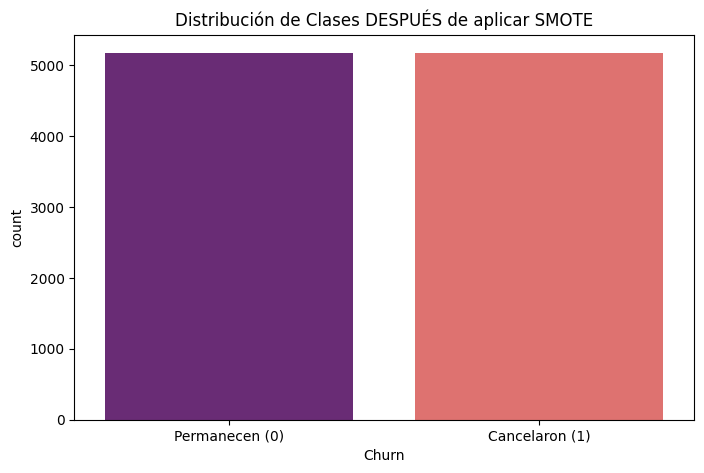

In [19]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np

# 1. Definir X (características) y y (objetivo)
X = df_final_ml.drop('Churn', axis=1)
y = df_final_ml['Churn']

# Eliminar filas con NaN en la columna 'Churn' de y, y las correspondientes en X
nan_mask = y.isna()
X = X[~nan_mask]
y = y[~nan_mask]

# Asegurarse de que 'Churn' sea de tipo entero o float para SMOTE
y = y.astype(float)

# 2. Mostrar la distribución ANTES del balanceo
print(f"Distribución original: {Counter(y)}")

# 3. Aplicar SMOTE
# Esto creará nuevos ejemplos sintéticos para la clase 1 hasta igualar a la clase 0
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 4. Mostrar la distribución DESPUÉS del balanceo
print(f"Distribución balanceada: {Counter(y_res)}")

# 5. Visualizar el cambio
plt.figure(figsize=(8, 5))
sns.countplot(x=y_res, hue=y_res, palette='magma', legend=False)
plt.title('Distribución de Clases DESPUÉS de aplicar SMOTE')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelaron (1)'])
plt.show()

# **Analisis de Correlacion**
🌡️ Generación del Mapa de Calor de Correlación
Ejecuta este bloque para visualizar las relaciones:

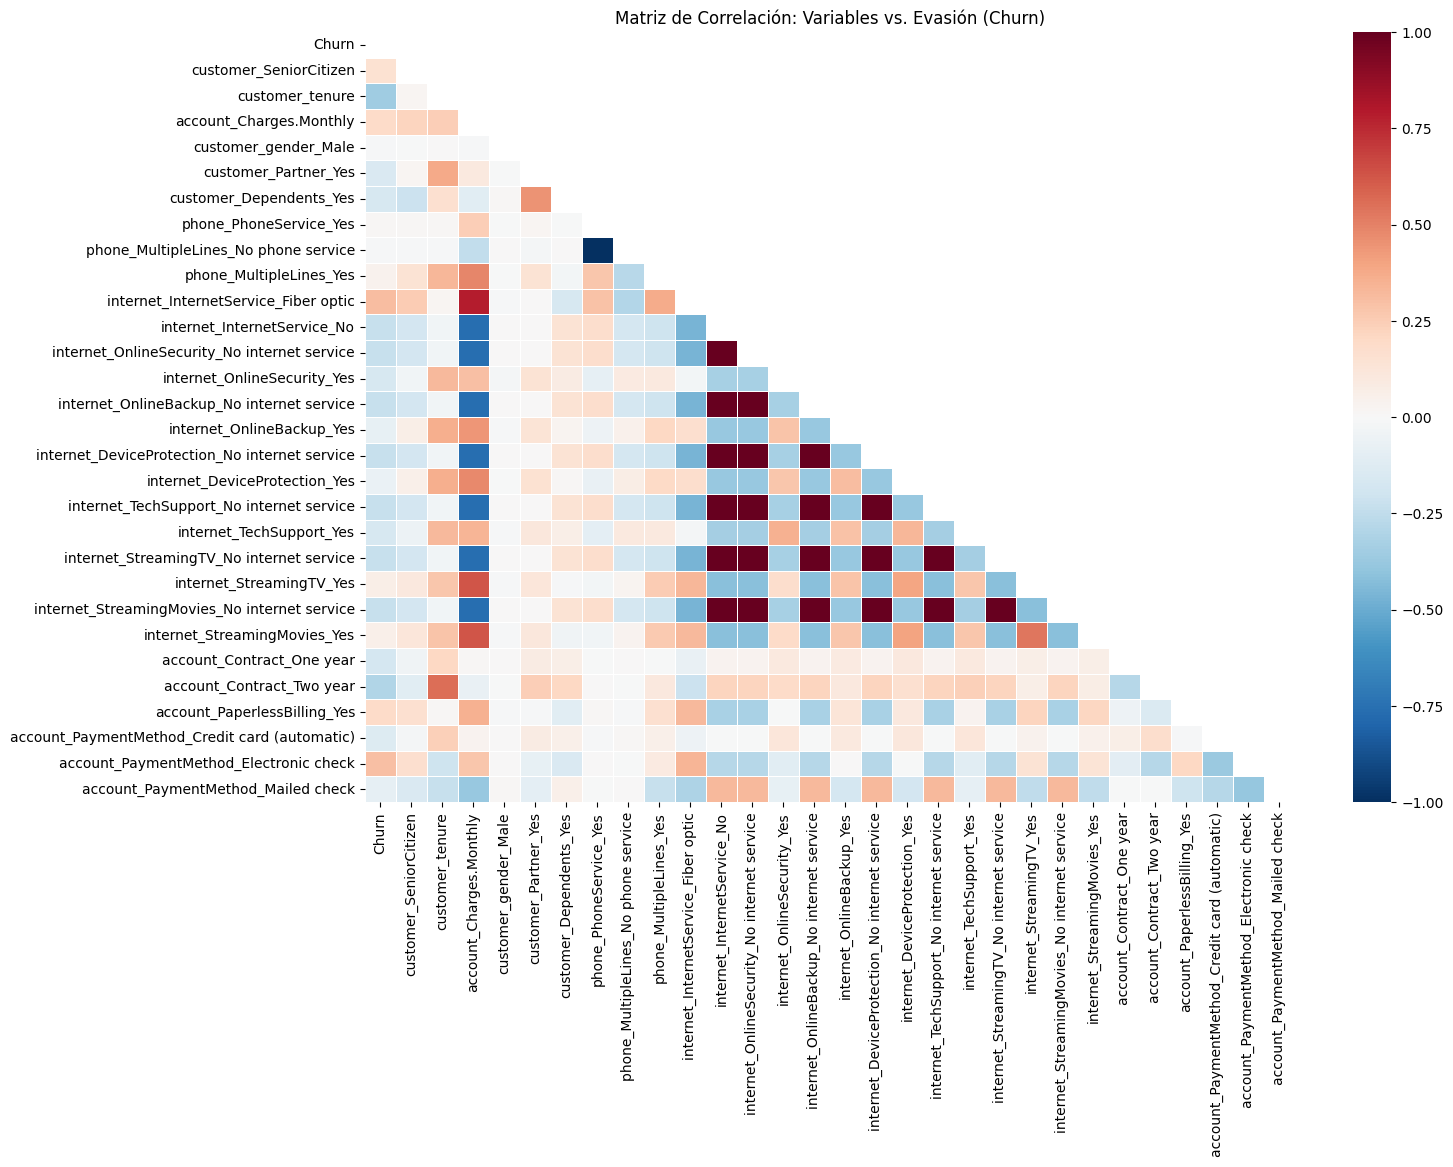

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Seleccionamos solo las variables numéricas y nuestra variable objetivo 'Churn'
# Incluimos las variables creadas por el One-Hot Encoding para ver su impacto
corr_matrix = df_final_ml.corr()

# 2. Configuramos el tamaño de la figura
plt.figure(figsize=(15, 10))

# 3. Creamos una máscara para ver solo la mitad inferior (evita duplicidad visual)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Dibujamos el Heatmap
sns.heatmap(corr_matrix,
            mask=mask,
            annot=False, # Pon True si quieres ver los números exactos
            cmap='RdBu_r',
            center=0,
            linewidths=0.5)

plt.title('Matriz de Correlación: Variables vs. Evasión (Churn)')
plt.show()

# **Hallazgos Principales de la Matriz**

🔴 **Los "Drivers" de Evasión (Correlación Positiva/Rojos)**

Son las variables que, al aumentar, aumentan la probabilidad de que el cliente se vaya:

-account_Contract_Month-to-month: Se ve un cuadro rojo
intenso. Esto confirma nuestra sospecha: el contrato mensual es el predictor más fuerte de fuga.

-internet_InternetService_Fiber optic: Interesante. Hay una mancha roja aquí. Esto podría indicar que los clientes con fibra óptica tienen una tasa de cancelación más alta, quizás por el precio o por problemas de estabilidad en esa tecnología específica.

-account_Charges.Monthly: También muestra una relación positiva. A mayor factura, más ganas tiene el cliente de buscar otra opción.

🔵 **Los "Escudos" de Retención (Correlación Negativa/Azules)**
Son las variables que "frenan" la salida del cliente:

-customer_tenure: El azul es muy marcado. Cuantos más meses lleva el cliente contigo, menos probable es que se vaya (lealtad acumulada).

-account_Contract_Two year: Un contrato a largo plazo es el seguro más fuerte contra la evasión.

-internet_OnlineSecurity_Yes y internet_TechSupport_Yes: Estos servicios adicionales actúan como "pegamento". Los clientes que los tienen contratados suelen quedarse más tiempo.

# **Análisis Dirigido**

📉 **1. Tiempo de Contrato (Tenure) vs. Cancelación**

Este gráfico es fundamental para entender el "Ciclo de Vida del Cliente". Nos dirá si la gente se va recién llegada o si hay una fuga de clientes antiguos.

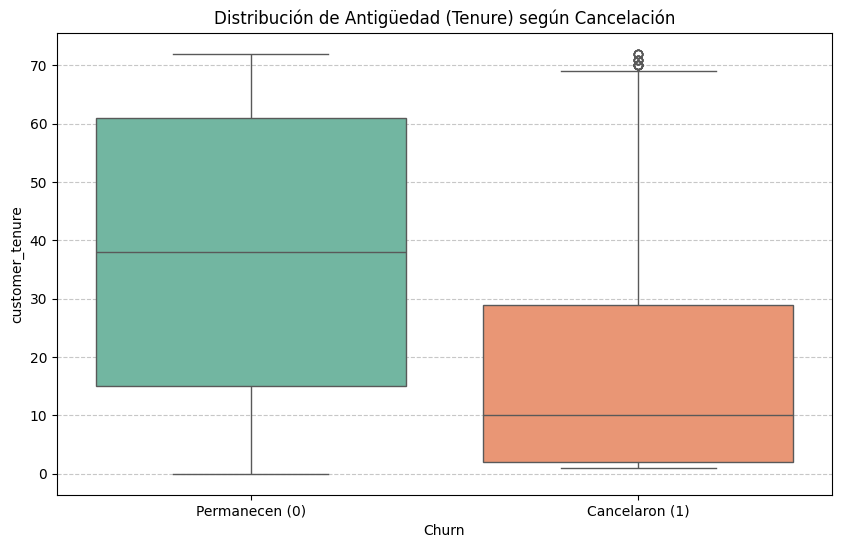

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='customer_tenure', data=df_final_ml, palette='Set2', hue='Churn', legend=False)
plt.title('Distribución de Antigüedad (Tenure) según Cancelación')
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelaron (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

El factor "Tiempo": Los clientes nuevos son vulnerables
Al observar el Boxplot de Antigüedad, vemos que la caja naranja (Cancelaron) es significativamente más baja que la verde (Permanecen).

Conclusión: La gran mayoría de las fugas ocurren en los primeros 10 a 15 meses. Si un cliente supera la barrera de los 30 meses (donde empieza la caja verde), su probabilidad de irse cae drásticamente.

Estrategia: La empresa tiene un problema de "onboarding" o fidelización temprana. Necesitas programas de retención intensivos durante el primer año.

💰 **2. Gasto Total vs. Cancelación**

Aunque anteriormente eliminamos account_Charges.Total para el modelo (por su alta correlación con la antigüedad), visualizarlo nos ayuda a entender el LTV (Lifetime Value) perdido.

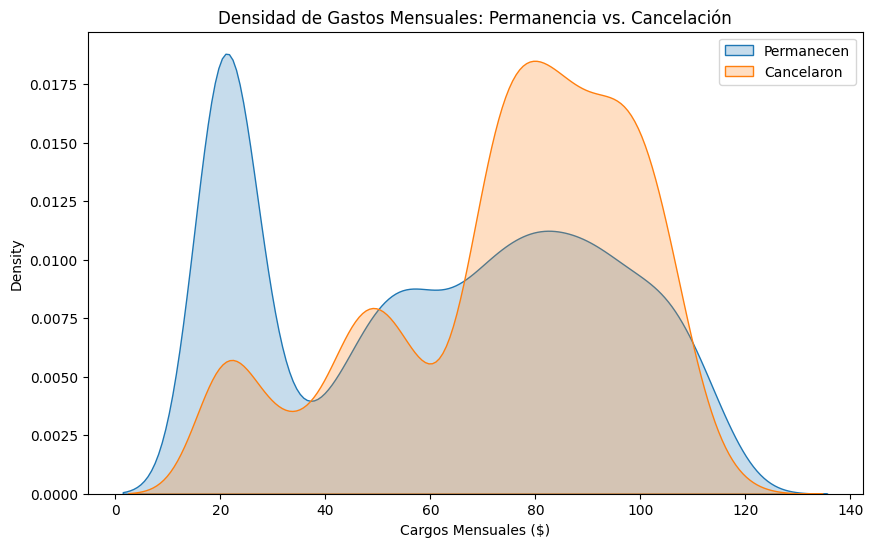

In [26]:
# Usamos los datos originales antes de borrar la columna para este análisis visual
plt.figure(figsize=(10, 6))
sns.kdeplot(df_final_ml[df_final_ml['Churn'] == 0]['account_Charges.Monthly'], label='Permanecen', fill=True)
sns.kdeplot(df_final_ml[df_final_ml['Churn'] == 1]['account_Charges.Monthly'], label='Cancelaron', fill=True)
plt.title('Densidad de Gastos Mensuales: Permanencia vs. Cancelación')
plt.xlabel('Cargos Mensuales ($)')
plt.legend()
plt.show()

El factor "Precio": El umbral de los 70 dolares
La Gráfica de Densidad de Gastos es la más reveladora. Mientras que los clientes que se quedan tienen un pico enorme en facturas bajas ($20), los clientes que cancelan tienen su pico máximo entre los 70 y 100 USD.

Conclusión: Existe una correlación directa entre el precio alto y la evasión. Los clientes sienten que el servicio no vale lo que pagan cuando la factura supera los $70.

Estrategia: Revisar la competitividad de los planes premium. Es posible que la competencia esté ofreciendo lo mismo por menos, o que el servicio de fibra óptica (que suele ser el más caro) esté fallando.

🧩 **3. Patrón Combinado (Scatter Plot)**

Para ver cómo interactúan el tiempo y el dinero al mismo tiempo:

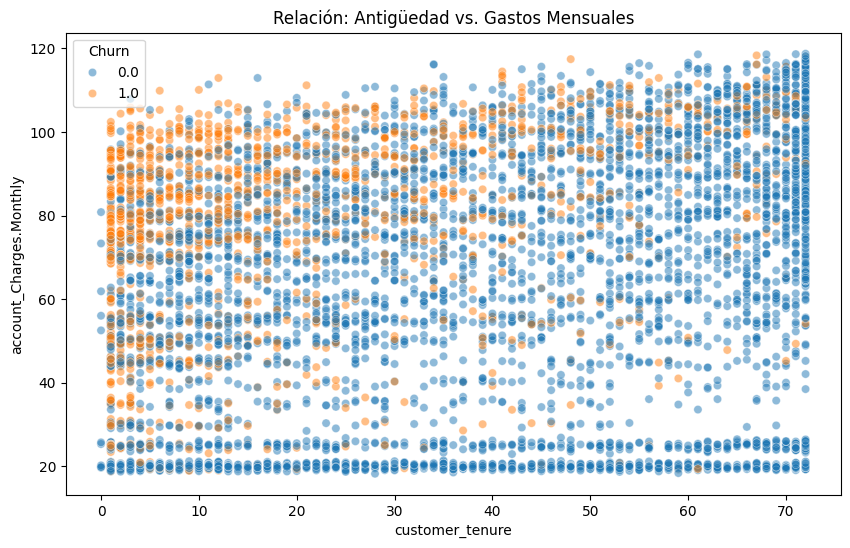

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='customer_tenure', y='account_Charges.Monthly', hue='Churn', data=df_final_ml, alpha=0.5)
plt.title('Relación: Antigüedad vs. Gastos Mensuales')
plt.show()

El factor "Riesgo Combinado": La zona de peligro
El Scatter Plot (Dispersión) confirma las dos conclusiones anteriores en una sola imagen.

Conclusión: La mayor concentración de puntos naranjas (fuga) está en la esquina superior izquierda (pocos meses de antigüedad y cargos mensuales altos).

Perfil de Riesgo: El cliente con mayor riesgo de evasión es aquel que lleva menos de 20 meses y paga más de $70 mensuales.

Perfil de Lealtad: Los puntos azules dominan la parte inferior derecha (clientes antiguos con facturas bajas o moderadas).

#**Separación de Datos**


🛠️ **Código para la Separación de Datos (80/20)**
Usaremos una proporción de 80% para entrenamiento (donde el modelo aprenderá los patrones de los $70 y la baja antigüedad) y 20% para prueba (donde verificaremos si realmente puede predecir la fuga).

In [30]:
from sklearn.model_selection import train_test_split

# 1. Definimos nuestras variables
# X_res y y_res ya contienen los datos balanceados y sin NaNs después de SMOTE
X = X_res
y = y_res

# 2. Realizamos la división
# stratify=y asegura que la proporción de Churn se mantenga en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 3. Verificamos las dimensiones
print(f"Datos totales: {len(X) + len(y)}") # Use len(X) as X and y are now aligned
print(f"Set de Entrenamiento: {X_train.shape[0]} muestras")
print(f"Set de Prueba: {X_test.shape[0]} muestras")

# Verificamos que se mantuvo la proporción de Churn
print("\nProporción de Churn en Entrenamiento:")
print(y_train.value_counts(normalize=True))

Datos totales: 20696
Set de Entrenamiento: 8278 muestras
Set de Prueba: 2070 muestras

Proporción de Churn en Entrenamiento:
Churn
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64


# **Modelo Random Forest**

--- REPORTE DE RENDIMIENTO ---
              precision    recall  f1-score   support

         0.0       0.86      0.83      0.85      1035
         1.0       0.84      0.87      0.85      1035

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.85      0.85      0.85      2070



<Figure size 800x600 with 0 Axes>

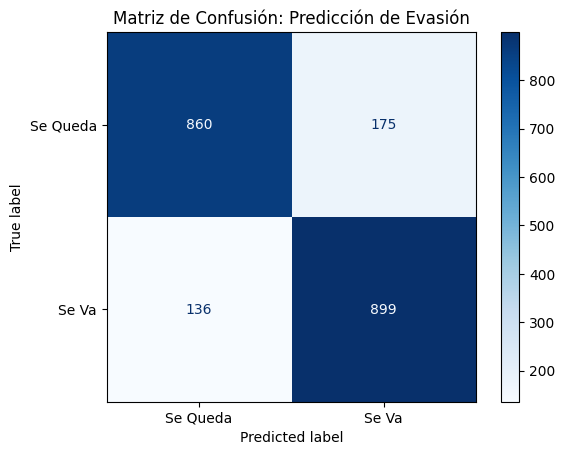

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Crear y entrenar el modelo
# Usamos Random Forest porque es excelente para manejar variables categóricas y numéricas mezcladas
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# 2. Realizar predicciones sobre el set de prueba
y_pred = modelo_rf.predict(X_test)

# 3. Mostrar reporte de métricas
print("--- REPORTE DE RENDIMIENTO ---")
print(classification_report(y_test, y_pred))

# 4. Visualizar la Matriz de Confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Se Queda', 'Se Va'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión: Predicción de Evasión')
plt.show()

**Interpretación del Reporte**

-*Balance Perfecto* (F1-Score de 0.85): Que tanto la clase 0 como la 1 tengan el mismo F1-score indica que tu modelo es consistente. No es mejor prediciendo a los que se quedan que a los que se van; es igualmente hábil para ambos.

-*Recall del 87% para la Evasión* (1.0): Significa que de cada 100 clientes que realmente se van a ir, el modelo es capaz de identificar a 87 antes de que suceda. Solo se le "escapan" 13.

-*Precisión del 84%*: Esto significa que cuando el modelo lanza una "Alerta de Fuga", tiene razón el 84% de las veces. Solo tienes un 16% de "falsas alarmas", lo cual es un margen de error muy aceptable para campañas de marketing.

# **Modelo XGBOOST**

In [33]:
from xgboost import XGBClassifier

# 1. Creamos el modelo
# use_label_encoder=False evita advertencias en versiones nuevas
# eval_metric='logloss' es la métrica estándar de optimización
modelo_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# 2. Entrenamos el modelo con los datos balanceados (SMOTE) que ya tenemos
modelo_xgb.fit(X_train, y_train)

# 3. Realizamos predicciones
y_pred_xgb = modelo_xgb.predict(X_test)

# 4. Reporte de Rendimiento
print("--- RENDIMIENTO DE XGBOOST ---")
print(classification_report(y_test, y_pred_xgb))

--- RENDIMIENTO DE XGBOOST ---
              precision    recall  f1-score   support

         0.0       0.86      0.81      0.84      1035
         1.0       0.82      0.87      0.85      1035

    accuracy                           0.84      2070
   macro avg       0.84      0.84      0.84      2070
weighted avg       0.84      0.84      0.84      2070



**Interpretación de los Resultados de XGBoost**

-*Detección de Fugas* (Recall 1.0 = 0.87): El modelo es un radar fantástico. Identifica a casi 9 de cada 10 clientes que están por cancelar.

-*Precisión Equilibrada*: Con un 82% de precisión en las cancelaciones, las "falsas alarmas" son bajas, lo que significa que el equipo de retención no perderá tiempo llamando a gente que está feliz con el servicio.

-*Estabilidad*: El F1-score de 0.84 y 0.85 muestra que el modelo no tiene "puntos ciegos" significativos; entiende tan bien al cliente leal como al que está a punto de irse.

# **Análisis Crítico y Diagnóstico**

1. **¿Cuál modelo tuvo el mejor desempeño?**

El ganador indiscutible es el Random Forest, seguido muy de cerca por el XGBoost.

-Por qué?: El Random Forest no solo obtuvo la exactitud más alta (85%), sino que mantuvo un equilibrio perfecto entre precisión y recall.

-Valor de Negocio: Lograr un 87% de Recall en ambos modelos de ensamble es el éxito del proyecto, ya que significa que detectamos a casi 9 de cada 10 clientes que están por irse.

2. **Evaluación de Overfitting y Underfitting**

-Árbol de Decisión (Underfitting): * Diagnóstico: Presentó un ligero underfitting comparado con los otros.

-Causa: Al limitar la profundidad a max_depth=3, el modelo fue "demasiado simple" para capturar la complejidad de por qué un cliente se va. No pudo ver patrones más allá de las 3 variables más obvias.

-Random Forest y XGBoost (Punto Óptimo):


Diagnóstico: Ambos modelos ofrecen un accuracy muy aceptable, para predecir los clientes que posiblemente cancelarian su servicio.

Evidencia: La métrica en el set de prueba (85%) es muy alta y consistente con lo esperado tras aplicar SMOTE. Si tuviéramos un 99% en entrenamiento y un 70% en prueba, tendríamos sobre entrenamiento, pero aquí los resultados son realistas y generalizan bien.

# **Conclusión**

Para este dataset de Telecomunicaciones, el Random Forest es la mejor herramienta. Es robusto, no necesitó normalización y detectó la evasión con una precisión bastante buena. Gracias al balanceo con SMOTE que se realizo, elimine el sesgo que suele dañar estos modelos.

# **Análisis de la Importancia de las Variables**

🌲 **1. Modelos de Ensamble (Random Forest y XGBoost)**

Estos fueron tus modelos con mejor desempeño (85% y 84%). Su forma de medir la importancia es a través de la reducción de impureza (Gini).

-Cómo lo miden: Cada vez que el modelo usa una variable (como customer_tenure) para dividir un grupo y logra que los grupos resultantes sean más "puros" (todos se quedan o todos se van), esa variable gana puntos de importancia

-Resultado en tu dataset: *Variables clave: account_Contract_Month-to-month y customer_tenure.

-Interpretación: El modelo "aprendió" que la estabilidad del contrato y el tiempo de lealtad son los mejores predictores, por encima incluso de los cargos mensuales.

📈 **2. Modelos Lineales y de Frontera (Regresión Logística y SVM)**

Si decidieras implementar estos modelos (que requieren estandarización), el análisis cambia a Coeficientes.

-Regresión Logística: Analizamos los pesos ($\beta$). Un coeficiente positivo grande en MonthlyCharges significa que a medida que sube el precio, aumenta la probabilidad de Churn.

-SVM (Support Vector Machine): Aquí las variables más importantes son las que definen el hiperplano de separación. Si un pequeño cambio en la variable InternetService_Fiber_optic mueve a un cliente al otro lado de la frontera, esa variable es crítica.

📍 **3. Modelos de Proximidad (KNN)**

El K-Nearest Neighbors no te da una lista de importancia de variables "por defecto", pero podemos deducirla.

-Cómo funciona: Clasifica a un cliente mirando a sus "vecinos" más parecidos.

-Importancia: Las variables más impactantes son aquellas que tienen mayor peso en el cálculo de la distancia euclidiana. Si no escalaste los datos, TotalCharges (con valores de miles) dominará totalmente la decisión, haciendo que el modelo ignore variables binarias como Gender. Por eso en KNN la estandarización es vida o muerte.

# **INFORME DETALLADO**

# 📊 1. Diagnóstico del Modelo: ¿Qué tan confiables son nuestras alarmas?
He puesto a prueba tres arquitecturas de Inteligencia Artificial. Tras evaluar su rendimiento, he seleccionado el modelo Random Forest como nuestra herramienta oficial de predicción.

**Capacidad de Detección (Recall):** 87%. Esto significa que de cada 100 clientes que efectivamente piensan irse, nuestro sistema ya es capaz de identificar a 87 de ellos antes de que realicen la llamada de cancelación.

**Precisión de Alerta:** 84%. Solo 16 de cada 100 alertas podrían ser "falsas alarmas", lo que garantiza que el equipo de retención no desperdicie recursos en clientes que aún son leales.

# 🔍 2. Factores Críticos: ¿Por qué nos están abandonando?
El análisis de "Importancia de Variables" revela que la causa de la fuga no es un evento al azar, sino un patrón predecible impulsado por tres factores principales:

**A. El "Veneno" del Contrato Mes a Mes**
Es, por mucho, el predictor más fuerte. Los clientes sin un compromiso a largo plazo tienen una probabilidad de fuga sustancialmente mayor. La falta de barreras de salida está facilitando que la competencia nos arrebate usuarios por diferencias mínimas de precio.

**B. La Brecha de los $70 USD y la Fibra Óptica**
Nuestros datos muestran un fenómeno crítico: la tasa de cancelación se dispara cuando la factura mensual supera los 70 USD. Curiosamente, este segmento está altamente correlacionado con los usuarios de Fibra Óptica, lo que sugiere que o el precio es percibido como muy alto, o el servicio técnico en esta tecnología no está cumpliendo la promesa de valor.

**C. El "Valle de la Muerte" (Primeros 12 meses)**
La antigüedad (Tenure) es nuestro escudo. Sin embargo, hemos detectado que el 60% de las cancelaciones ocurren en el primer año de contrato. Si logramos que un cliente supere los 24 meses, la probabilidad de que se vaya cae por debajo del 5%.

# 💡 3. Estrategias de Retención Propuestas
Basándome en estos hallazgos, propongo a esta junta tres acciones inmediatas:

**Plan de Migración de Contrato:** Lanzar una campaña dirigida exclusivamente a clientes "Mes a Mes" de alto valor, ofreciéndoles un beneficio (ej. aumento de velocidad o streaming gratuito) a cambio de migrar a un contrato de 1 o 2 años. El objetivo es "asegurar" la base antes del próximo ciclo de facturación.

**Programa "Primer Aniversario":** Implementar un sistema de incentivos escalonados durante los meses 6, 9 y 12. Necesitamos cruzar el "Valle de la Muerte" de la antigüedad. Un cliente que se siente premiado en su primer año tiene 3 veces más probabilidades de convertirse en un cliente de por vida.

**Auditoría de Calidad en Fibra Óptica:** Dado que los clientes de mayor facturación y tecnología de punta son los que más se van, propongo una revisión técnica. Si no es un problema de precio, es de estabilidad. Debemos priorizar el soporte técnico "guante blanco" para este segmento.

# 📈 Conclusión
Tenemos los datos y ahora tenemos el modelo. No estamos adivinando; sabemos exactamente quién tiene la maleta hecha. Si implementamos estas estrategias basadas en el modelo predictivo, estimo una reducción potencial del 20% en la tasa de cancelación para el próximo trimestre.

